In [66]:
from OptimalBattery import simulate as sim
import numpy as np
import matplotlib.pyplot as plt
import HierarchBayesParcel.evaluation as ev
import torch as pt
import OptimalBattery.util as ut
from numpy.linalg import eigh
from scipy.stats import pearsonr
from Functional_Fusion.dataset import DataSetMDTB
import PcmPy as pcm
import seaborn as sns
import os
import pandas as pd
import pickle
from PcmPy.sim import make_signal
from OptimalBattery.plot import plot_correlations
from sklearn.cluster import MiniBatchKMeans
from sklearn.manifold import spectral_embedding


# generate true Us

In [67]:
n_subs = 24
n_parcel = 4
n_voxels  = 100
n_tasks = 29
offsets = [1e-12,1e-10,1e-8,1e-6,1e-4,1e-2,1,1e2,1e4,1e6,1e8,1e10,1e12]

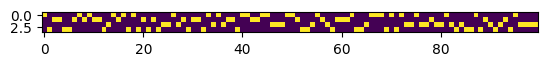

In [68]:
U_true = sim.generate_Us(s= n_subs, k = n_parcel, p = n_voxels, type= 'hard')
plt.imshow(U_true[2])

# Generate test data (random Vs)

In [69]:
def evaluate_combinations(D, Vs, ytest, vtest):
    # Create a new column with combinations as tuples to make them hashable
    D['combination_tuple'] = D['combination'].apply(lambda x: tuple(x))
    
    # Get unique combinations
    unique_combinations = D['combination_tuple'].unique()
    
    # Initialize a dictionary to store cos_HBP for each unique combination
    mse_ols_dict = {}
    cos_ols_dict = {}

    ytest = pt.tensor(ytest,dtype=pt.float32)
    vtest = pt.tensor(vtest,dtype=pt.float32)
    
    # Loop over each unique combination
    for i, comb_tuple in enumerate(unique_combinations):
        if i % 100 == 0:
            print(f"Processing combination: {i}")
        
        # Get the task subset indices and corresponding data
        task_subset_indices = list(comb_tuple)
        V_subset = Vs[task_subset_indices, :]
        V_subset = V_subset - np.mean(V_subset, axis=0)
        V_subset = V_subset / np.sqrt(np.sum(V_subset**2, axis=0))
        rank_V_subset = np.linalg.matrix_rank(V_subset)
        if rank_V_subset < V_subset.shape[1]:
            continue  # Skip this combination if the rank condition is not met

        y_subset = V_subset @ U_true
        y_subset = y_subset + np.random.normal(0, 0.001, y_subset.shape)

        U_hat_ols = sim.estimate_Us_ols(y_subset, V_subset)
        mse_ols = sim.U_MSE(U_true, U_hat_ols)
        
        U_hat_ols = pt.tensor(U_hat_ols,dtype=pt.float32)
        cos_ols = ev.coserr(ytest,vtest,U_hat_ols).mean().cpu().numpy()
        cos_ols = cos_ols.item()
        
        # Store the result in the dictionary
        mse_ols_dict[comb_tuple] = mse_ols
        cos_ols_dict[comb_tuple] = cos_ols
    
    # Map the computed cos_HBP values back to the DataFrame
    D['mse_ols'] = D['combination_tuple'].map(mse_ols_dict)
    D['cos_ols'] = D['combination_tuple'].map(cos_ols_dict)
    
    return D

# Random V Library

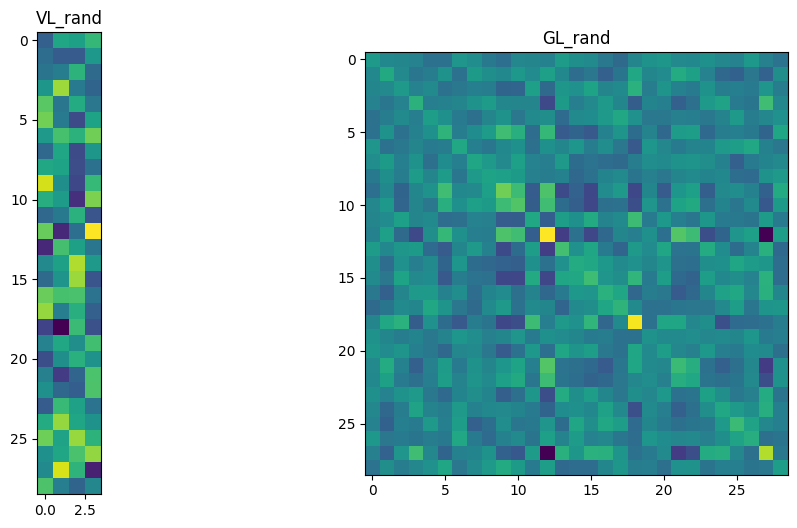

In [70]:
VL_rand = Vs = np.random.normal(0, 1, (n_tasks, n_parcel))
VL_rand = VL_rand - np.mean(VL_rand, axis=0)
VL_rand = VL_rand / np.sqrt(np.sum(VL_rand**2, axis=0))
GL_rand = VL_rand @ VL_rand.T


V_test = VL_rand
y_test = V_test @ U_true
y_test = y_test + np.random.normal(0, 0.001, y_test.shape)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(VL_rand)
ax[0].set_title('VL_rand')

ax[1].imshow(GL_rand)
ax[1].set_title('GL_rand')

plt.show()

In [71]:
D_rand = ut.build_combinations(GL_rand, strategy='random',offs = offsets,n_iter=240000,n_tasks=8,seed=14)
D_rand = evaluate_combinations(D_rand, VL_rand, y_test, V_test)
# check if there is any rows with empty cos_ols


Processing combination: 0
Processing combination: 100
Processing combination: 200
Processing combination: 300
Processing combination: 400
Processing combination: 500
Processing combination: 600
Processing combination: 700
Processing combination: 800
Processing combination: 900
Processing combination: 1000
Processing combination: 1100
Processing combination: 1200
Processing combination: 1300
Processing combination: 1400
Processing combination: 1500
Processing combination: 1600
Processing combination: 1700
Processing combination: 1800
Processing combination: 1900
Processing combination: 2000
Processing combination: 2100
Processing combination: 2200
Processing combination: 2300
Processing combination: 2400
Processing combination: 2500
Processing combination: 2600
Processing combination: 2700
Processing combination: 2800
Processing combination: 2900
Processing combination: 3000
Processing combination: 3100
Processing combination: 3200
Processing combination: 3300
Processing combination: 34

In [72]:
# remove any rows with any nan values
D_rand = D_rand.dropna(subset=['cos_ols'])


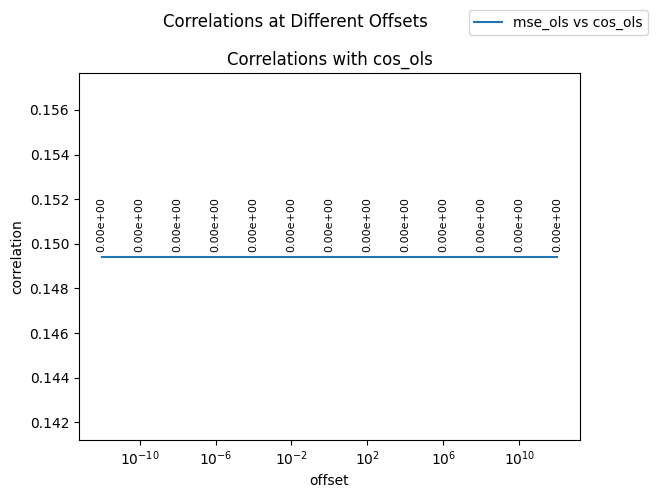

In [73]:
plot_correlations(D_rand, x_vars=['mse_ols'], y_vars=['cos_ols'],show_p_values=True)

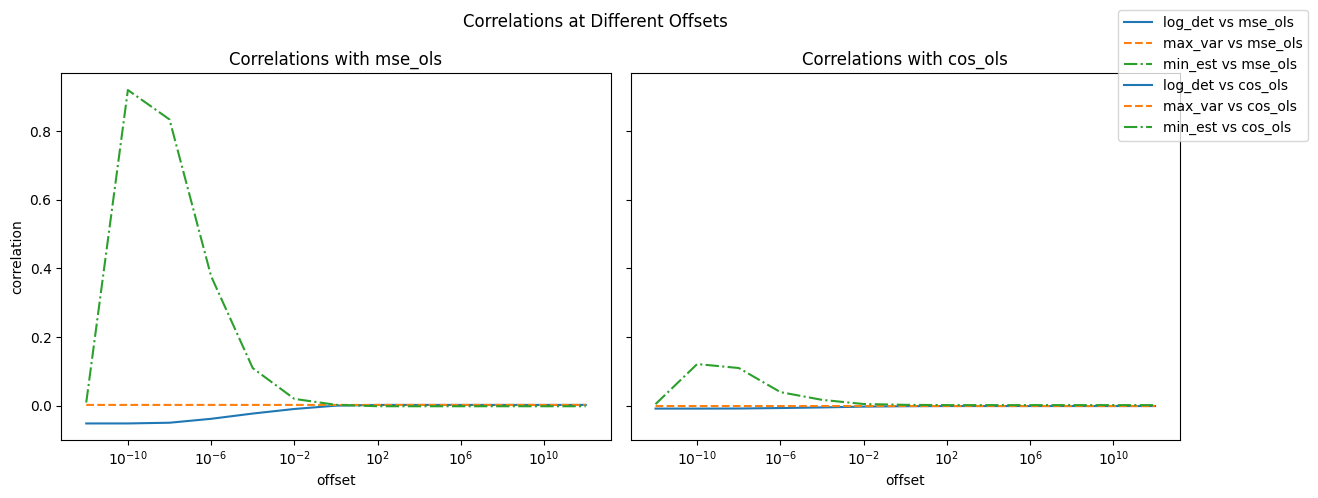

In [74]:
plot_correlations(D_rand, x_vars=['log_det','max_var','min_est'], y_vars=['mse_ols','cos_ols'])

# orthogonal V library

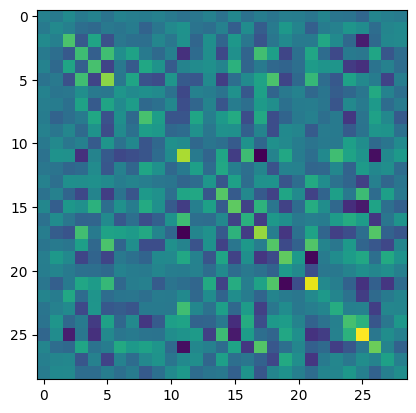

In [50]:
GL_orth = np.eye(n_tasks)
YL_orth = make_signal(G = GL_orth,n_channel=n_voxels,make_exact= True)
def kmeans_dictionary(n_parcels, Y):
    """
    Create the initial dictionary using K-Means clustering

    Args:
        n_parcels (int): number of parcels
        Y (np.ndarray): fMRI data (n_obs, n_subjects * n_voxels)

    Returns:
        dict_init (np.ndarray): initial dictionary (n_parcels, n_obs)
    """

    kmeans = MiniBatchKMeans(n_clusters=n_parcels, random_state=2,
                             batch_size=200, n_init=10)
    kmeans = kmeans.fit(Y.T)

    dict_init_ = kmeans.cluster_centers_
    dict_init = (dict_init_.T / np.sqrt((dict_init_ ** 2).sum(1))).T
    similarity = np.exp(np.corrcoef(dict_init))
    embedding = spectral_embedding(similarity, n_components=1)
    order = np.argsort(embedding.T).ravel()
    dict_init = dict_init[order]

    return dict_init.T



VL_orth = kmeans_dictionary(n_parcel, YL_orth)
VL_orth = VL_orth - np.mean(VL_orth, axis=0)
VL_orth = VL_orth / np.sqrt(np.sum(VL_orth**2, axis=0))

V_test = VL_orth
y_test = V_test @ U_true
y_test = y_test + np.random.normal(0, 2, y_test.shape)

GL_orth = VL_orth @ VL_orth.T
plt.imshow(GL_orth)


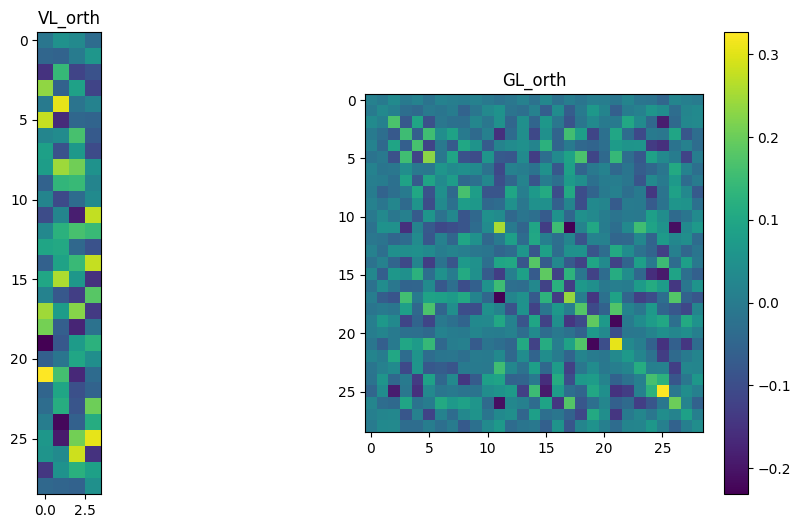

In [51]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(VL_orth)
ax[0].set_title('VL_orth')

im2 = ax[1].imshow(GL_orth)
ax[1].set_title('GL_orth')
fig.colorbar(im2, ax=ax[1]) 

plt.show()

In [52]:
D_orth = ut.build_combinations(GL_orth, strategy='random',offs = offsets,n_iter=10000,n_tasks=8,seed=14)
D_orth = evaluate_combinations(D_orth, VL_orth, y_test, V_test)




Processing combination: 0
Processing combination: 100
Processing combination: 200
Processing combination: 300
Processing combination: 400
Processing combination: 500
Processing combination: 600
Processing combination: 700
Processing combination: 800
Processing combination: 900
Processing combination: 1000
Processing combination: 1100
Processing combination: 1200
Processing combination: 1300
Processing combination: 1400
Processing combination: 1500
Processing combination: 1600
Processing combination: 1700
Processing combination: 1800
Processing combination: 1900
Processing combination: 2000
Processing combination: 2100
Processing combination: 2200
Processing combination: 2300
Processing combination: 2400
Processing combination: 2500
Processing combination: 2600
Processing combination: 2700
Processing combination: 2800
Processing combination: 2900
Processing combination: 3000
Processing combination: 3100
Processing combination: 3200
Processing combination: 3300
Processing combination: 34

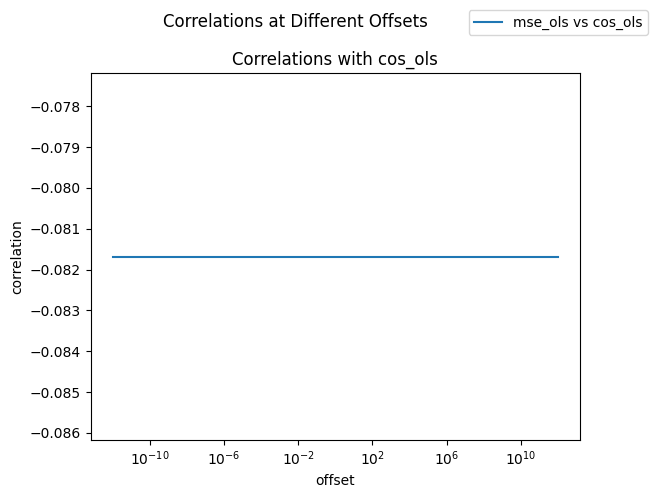

In [53]:
plot_correlations(D_orth, x_vars=['mse_ols'], y_vars=['cos_ols'])

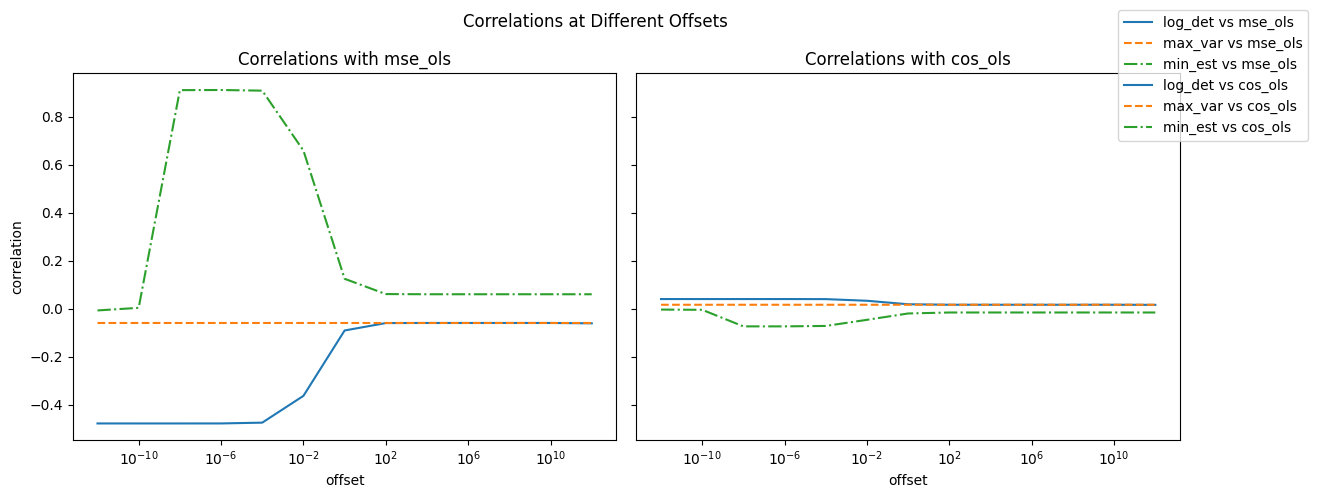

In [54]:
plot_correlations(D_orth, x_vars=['log_det','max_var','min_est'], y_vars=['mse_ols','cos_ols'])

# Custom Vs

In [55]:
def custom_G(n_tasks=16, n_groups=4, group_size=4, target_corr=0.4, variance_factors=[1.0, 0.75, 0.5, 0.25]):
    G = np.zeros((n_tasks, n_tasks))
    task_index = 0

    for group in range(n_groups):
        variances = variance_factors

        # Compute covariances based on desired correlation
        covariances = target_corr * np.outer(variance_factors, variance_factors)
        np.fill_diagonal(covariances, variances)

        # Place the block into G
        start, end = task_index, task_index + group_size
        G[start:end, start:end] = covariances

        task_index += group_size

    return G

In [56]:
def add_correlated_tasks_info(df, group_size):
    """Adds the number of correlated tasks and pairs to the dataframe."""
    n_correlated_tasks_list = []
    n_correlated_pairs_list = []
    for comb in df['combination']:
        group_indices = [task_index // group_size for task_index in comb]
        from collections import Counter
        counts = Counter(group_indices)

        n_correlated_tasks = sum(count for count in counts.values() if count > 1)
        n_correlated_pairs = sum(count * (count - 1) // 2 for count in counts.values())
        n_correlated_tasks_list.append(n_correlated_tasks)
        n_correlated_pairs_list.append(n_correlated_pairs)

    df['n_correlated_tasks'] = n_correlated_tasks_list
    df['n_correlated_pairs'] = n_correlated_pairs_list
    return df

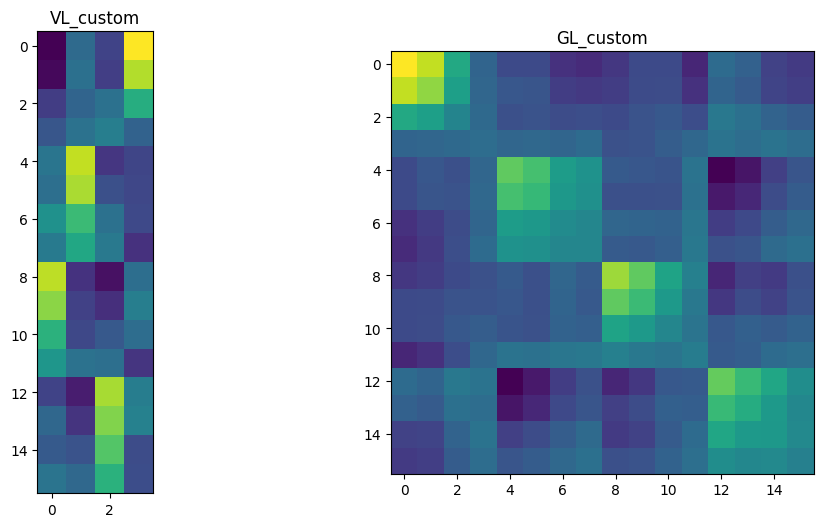

In [57]:
GL_custom = custom_G(n_tasks=16, n_groups=4, group_size=4, target_corr=1, variance_factors=[1.0, 0.75, 0.5, 0.25])
Y_custom = make_signal(G = GL_custom,n_channel=n_voxels,make_exact= True)
VL_custom = kmeans_dictionary(n_parcel, Y_custom)
VL_custom = VL_custom - np.mean(VL_custom, axis=0)
VL_custom = VL_custom / np.sqrt(np.sum(VL_custom**2, axis=0))

V_test = VL_custom
y_test = V_test @ U_true
y_test = y_test + np.random.normal(0, 2, y_test.shape)

GL_custom = VL_custom @ VL_custom.T
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(VL_custom)
ax[0].set_title('VL_custom')

ax[1].imshow(GL_custom)
ax[1].set_title('GL_custom')

plt.show()

In [58]:
D_custom = ut.build_combinations(GL_custom, strategy='random',n_iter=10000,n_tasks=8,seed=14)
D_custom = evaluate_combinations(D_custom, VL_custom, y_test, V_test)

group_size = 4
D_custom = add_correlated_tasks_info(D_custom, group_size)



Processing combination: 0
Processing combination: 100
Processing combination: 200
Processing combination: 300
Processing combination: 400
Processing combination: 500
Processing combination: 600
Processing combination: 700
Processing combination: 800
Processing combination: 900
Processing combination: 1000
Processing combination: 1100
Processing combination: 1200
Processing combination: 1300
Processing combination: 1400
Processing combination: 1500
Processing combination: 1600
Processing combination: 1700
Processing combination: 1800
Processing combination: 1900
Processing combination: 2000
Processing combination: 2100
Processing combination: 2200
Processing combination: 2300
Processing combination: 2400
Processing combination: 2500
Processing combination: 2600
Processing combination: 2700
Processing combination: 2800
Processing combination: 2900
Processing combination: 3000
Processing combination: 3100
Processing combination: 3200
Processing combination: 3300
Processing combination: 34

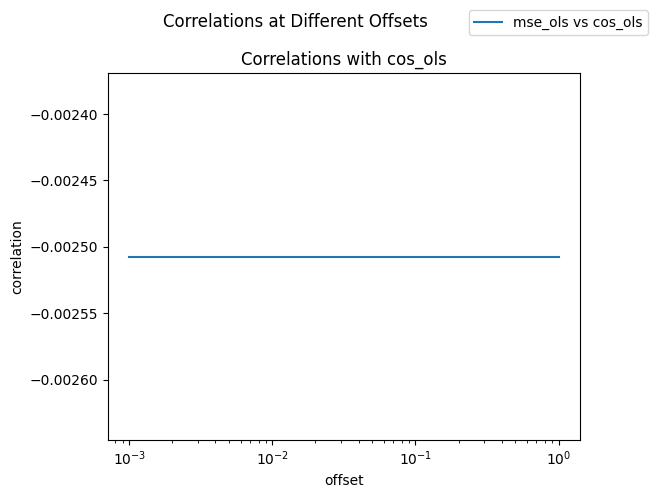

In [59]:
plot_correlations(D_custom, x_vars=['mse_ols'], y_vars=['cos_ols'])

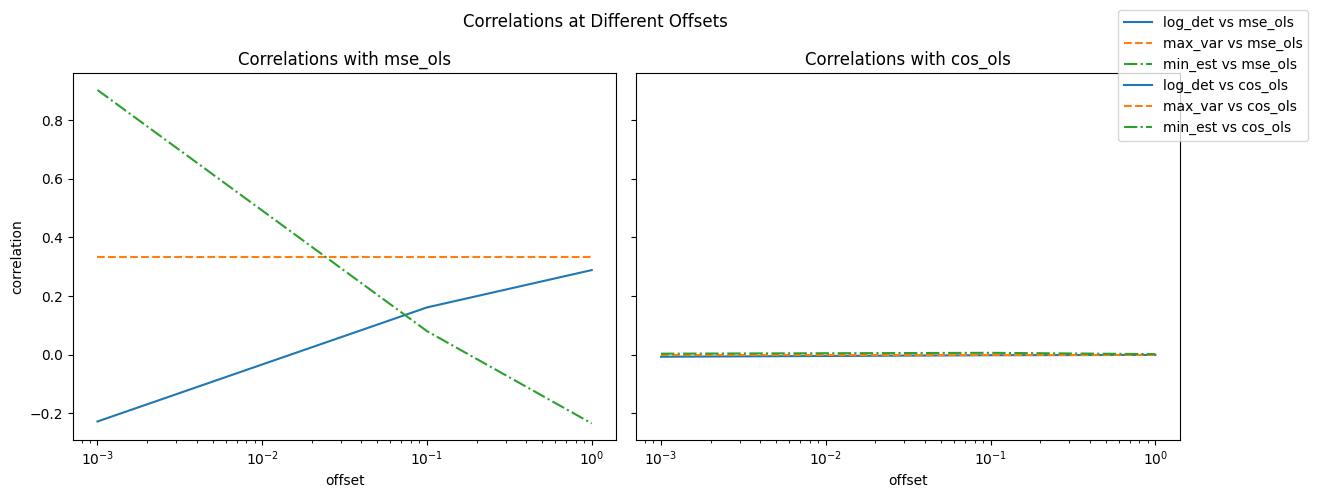

In [60]:
plot_correlations(D_custom, x_vars=['log_det','max_var','min_est'], y_vars=['mse_ols','cos_ols'])

# MDTB Vs

In [21]:
# mdtb vs based on HBP
model_dir = 'Y:/data/Cerebellum/ProbabilisticParcellationModel/Models'
if not os.path.exists(model_dir):
    model_dir = '/cifs/diedrichsen/data/Cerebellum/ProbabilisticParcellationModel/Models'
    
model_name = f'/Models_03/NettekovenSym32_space-MNISymC2'
fname = model_dir + model_name
with open(fname + '.pickle', 'rb') as file:
        full_model = pickle.load(file)[0]

# load emission model & Vs for mdtb ses-1
mdtb_1_emission = full_model.emissions[0]
mdtb_1_Vs = mdtb_1_emission.V

#make into np array
VL_mdtb = mdtb_1_Vs.detach().numpy()
GL_mdtb = VL_mdtb @ VL_mdtb.T

mdtb_2_emission = full_model.emissions[1]
mdtb_2_Vs = mdtb_2_emission.V

#make into np array
VL_mdtb_2 = mdtb_2_Vs.detach().numpy()
GL_mdtb_2 = VL_mdtb_2 @ VL_mdtb_2.T

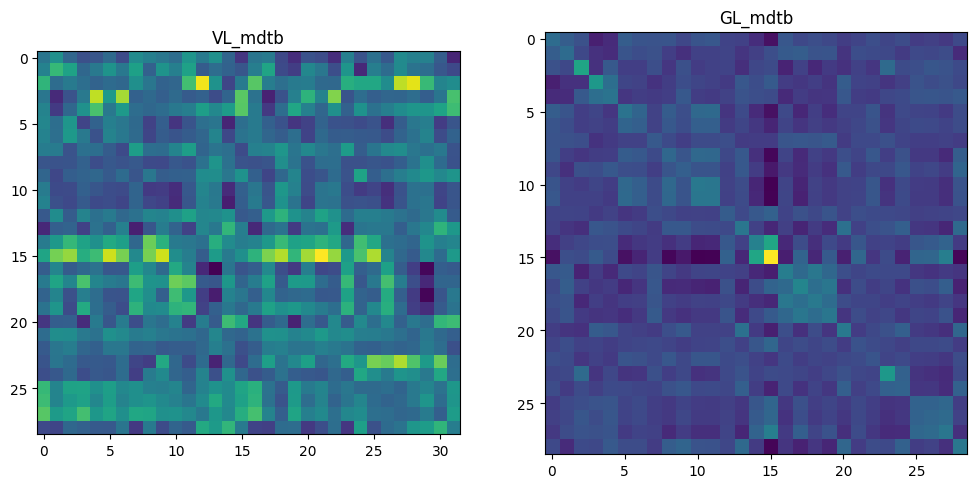

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(VL_mdtb)
ax[0].set_title('VL_mdtb')

ax[1].imshow(GL_mdtb)
ax[1].set_title('GL_mdtb')

plt.show()

In [ ]:
D_mdtb = ut.build_combinations(GL_mdtb, strategy='random',n_iter=400,n_tasks=8,seed=3)
A_mdtb = D_mdtb[D_mdtb['offset'] == 0.001]
A_mdtb = evaluate_U_MSE(A_mdtb, VL_mdtb, y_test, V_test)

